# Stroke Prediction — Data Mining Project

**Can we predict who is at risk of a stroke — before it happens?**

Stroke is one of the leading causes of death and long-term disability worldwide. The problem is that it often strikes without warning. This project attempts to answer a practical question: given a patient's basic medical profile, can we identify who is most likely to suffer a stroke?

The dataset contains **5,110 patient records** with features like age, glucose level, BMI, and lifestyle factors. The target variable is binary: did the patient have a stroke or not?

**The main challenge here isn't just accuracy — it's catching as many real stroke cases as possible, even if that means raising some false alarms.** In clinical settings, missing a high-risk patient is far worse than sending someone for an unnecessary check-up. This principle shapes every modelling decision made below.

---

**Project structure:**

0. Setup
1. Exploratory Data Analysis — understanding the data before touching it
2. Preprocessing — cleaning, imputing, and encoding
3. Model Training — Logistic Regression, Random Forest, XGBoost, Neural Network
4. Evaluation
6. Clustering — can we find natural patient risk groups without using the label?
7. Conclusions

## 0. Setup

In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, matthews_corrcoef, silhouette_score
)
from imblearn.over_sampling import SMOTE

# Optional libraries
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('[INFO] XGBoost not installed. Skipping XGBoost model.')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print('[INFO] TensorFlow not installed. Skipping ANN model.')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('[INFO] SHAP not installed. Skipping SHAP explainability.')

In [62]:
# Colour palette and plot defaults
PURPLE     = '#4B3F5B'
TEAL       = '#2A9D8F'
ORANGE     = '#E76F51'
GOLD       = '#E9C46A'
BLACK_NAVY = '#0B1120'
NAVY = '#94A3B8'

ALPHA      = 0.75
THRESHOLD  = 0.25   # Medical context: prioritise Recall

MODEL_COLORS = {'LR': PURPLE, 'RF': TEAL, 'XGB': ORANGE, 'ANN': GOLD}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F8F8',
    'axes.edgecolor':    '#CCCCCC',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        '#DDDDDD',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

---
## 1. Data Loading & First Look

Before doing anything, I want to understand what I'm working with — column types, ranges, and whether there are any obvious problems.

In [63]:
df_raw = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f'Shape  : {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Shape  : (5110, 12)
Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [64]:
info_df = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'missing':  df_raw.isnull().sum(),
    'missing%': (df_raw.isnull().mean() * 100).round(2)
})
display(info_df)
df_raw.describe()

,dtype,missing,missing%
id,int64,0,0.00
gender,object,0,0.00
age,float64,0,0.00
hypertension,int64,0,0.00
heart_disease,int64,0,0.00
ever_married,object,0,0.00
work_type,object,0,0.00
Residence_type,object,0,0.00
avg_glucose_level,float64,0,0.00
bmi,float64,201,3.93


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [65]:
df_raw.describe(include=['object', 'category'])

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


**A few things I noticed right away:**

- **BMI** has 201 missing values (~3.9%). That's enough to matter, but not so many that we should drop the column — we'll need to impute them carefully.
- The `id` column is just a row identifier with no predictive value — it'll be dropped.
- `gender` has an 'Other' category with only **1 record**. That single record can't meaningfully represent a group and could confuse models, so I'll remove it.

---
## 2. Exploratory Data Analysis (EDA)

I want to explore the data visually before building any model. The goal is to understand which features seem to separate stroke from non-stroke patients, and to check for patterns that should inform preprocessing decisions.


### 2.1 How Imbalanced Is the Target?

The first thing to check with medical data is the class split — because if 95% of patients didn't have a stroke, a model that just predicts 'no stroke' every time would score 95% accuracy while being completely useless.

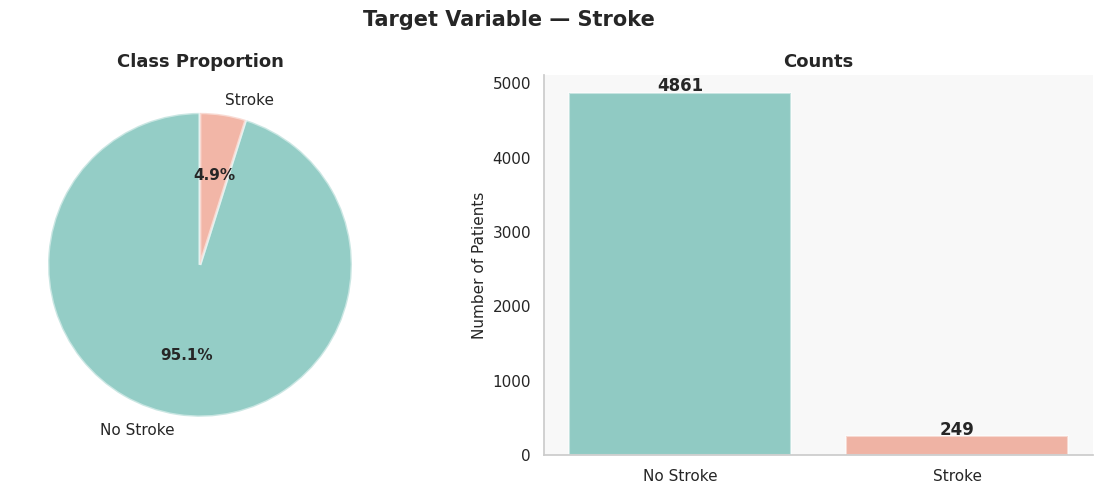

In [66]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable — Stroke', fontsize=15, fontweight='bold')

counts = df_raw['stroke'].value_counts()
labels = ['No Stroke', 'Stroke']
colors = [TEAL, ORANGE]

wedges, texts, autotexts = axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'alpha': 0.5})

for autotext in autotexts:
    autotext.set_fontweight('bold')

axes[0].set_title('Class Proportion')

axes[1].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, alpha=0.5)

for i, count in enumerate(counts):
    axes[1].text(i, count + 30, str(count), ha='center', fontweight='bold', fontsize=12)

axes[1].set_title('Counts')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

**What this tells us:**

Only **4.87%** of patients had a stroke — that's a roughly **1:19 imbalance**. This is the single most important characteristic of this dataset and it affects everything that follows.

If I train a model naively on this data, it will learn that saying 'no stroke' is almost always correct, and it will never actually learn what makes someone high-risk. To fix this, I'll use two complementary strategies:
- **SMOTE** (Synthetic Minority Oversampling) — generate synthetic stroke cases so the model trains on a balanced dataset
- **Custom decision threshold** — instead of predicting 'stroke' only above 50% probability, I'll lower the bar to catch more borderline cases

### 2.2 Do Continuous Features Differ Between Groups?


Here I'm comparing the distributions of `age`, `avg_glucose_level`, and `bmi` between patients who had a stroke and those who didn't. The curves show the **shape** of each distribution — if the orange (stroke) curve is shifted noticeably from the green (no stroke) one, that feature is probably predictive.

I'm using the **Mann-Whitney U test** to check statistical significance — it's a non-parametric test that doesn't assume normal distributions, which is appropriate here since BMI and glucose are skewed.

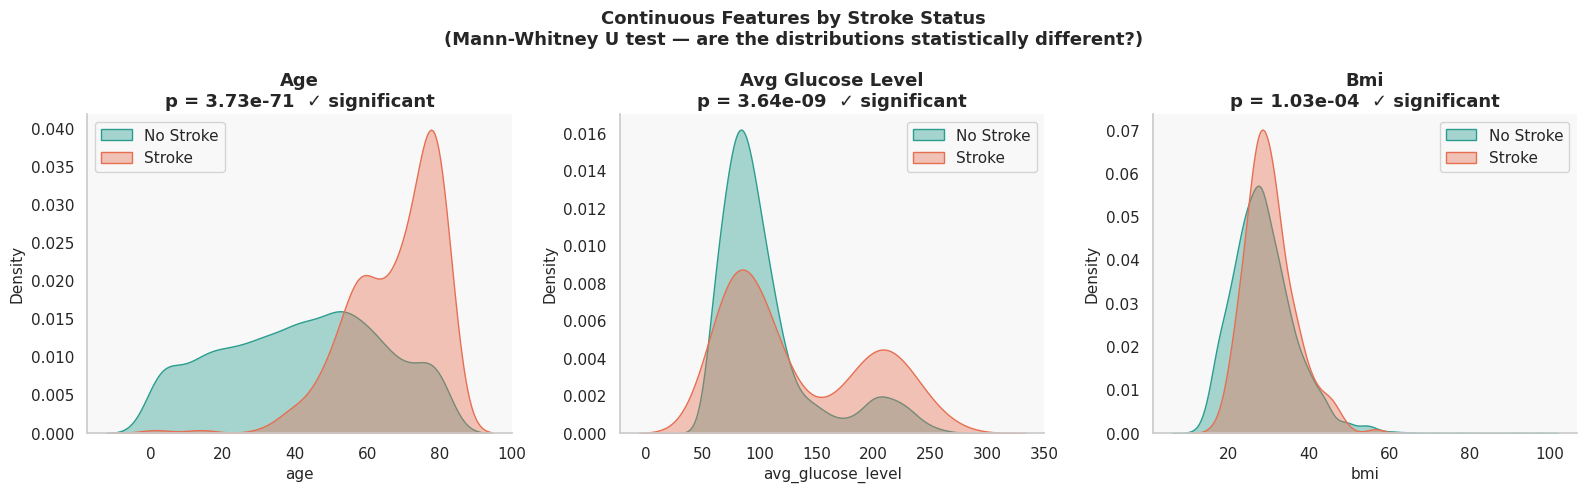

In [67]:
continuous_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Continuous Features by Stroke Status\n(Mann-Whitney U test — are the distributions statistically different?)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, continuous_cols):
    no_stroke = df_raw.loc[df_raw['stroke'] == 0, col].dropna()
    stroke    = df_raw.loc[df_raw['stroke'] == 1, col].dropna()
    _, p      = stats.mannwhitneyu(no_stroke, stroke, alternative='two-sided')

    sns.kdeplot(no_stroke, ax=ax, color=TEAL,   label='No Stroke', fill=True, alpha=0.4)
    sns.kdeplot(stroke,    ax=ax, color=ORANGE, label='Stroke',    fill=True, alpha=0.4)
    sig = '  ✓ significant' if p < 0.05 else ''
    ax.set_title(f"{col.replace('_', ' ').title()}\np = {p:.2e}{sig}")
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

**Reading these graphs:**

- **Age** — This feature shows a clear distinction between the two groups. The orange (stroke) curve peaks around age 70-80, while the green curve peaks around 40. Stroke patients are significantly older. The p-value is essentially zero — this is a very strong signal.

- **Average Glucose Level** — there's a clear rightward shift for stroke patients. Notably, the stroke curve has a long tail at high glucose values (200+), which is associated with diabetes. This is statistically significant but with more overlap than age.

- **BMI** — the distributions are surprisingly similar. Stroke patients have a slightly higher BMI on average, but the difference is small and the curves nearly overlap. BMI alone is probably not a strong predictor — it works better in combination with other features.

The takeaway: **age is by far the strongest single predictor**, followed by glucose. BMI matters less than I initially expected.

### 2.3 How Do Categorical Features Relate to Stroke Risk?


For each categorical feature, I'm showing the stroke rate (percentage of people in that group who had a stroke). Bars above the 5% baseline are coloured orange — they're the groups with elevated risk.

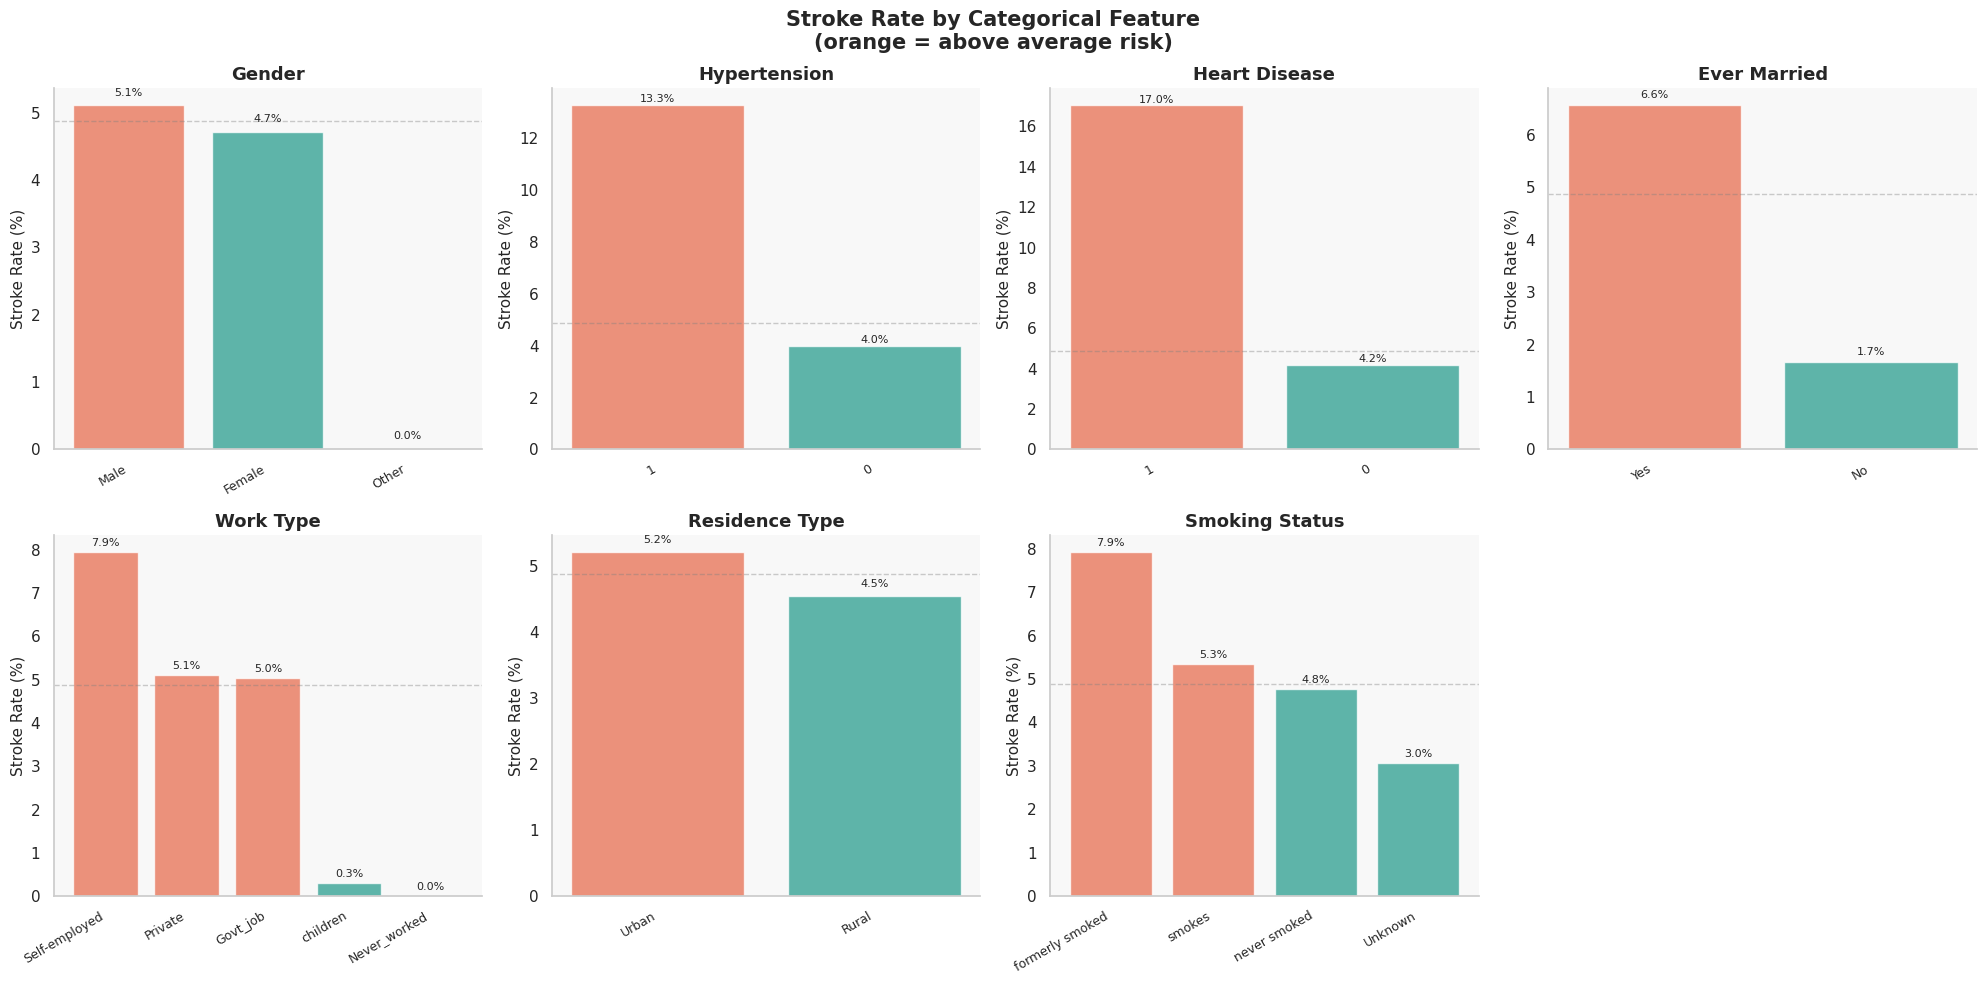

In [68]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Stroke Rate by Categorical Feature\n(orange = above average risk)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rate = df_raw.groupby(col)['stroke'].mean().sort_values(ascending=False)
    bar_colors = [ORANGE if v > 0.05 else TEAL for v in rate.values]
    bars = ax.bar(range(len(rate)), rate.values * 100, color=bar_colors,
                  edgecolor='white', alpha=ALPHA)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Stroke Rate (%)')
    ax.axhline(df_raw['stroke'].mean() * 100, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                f"{bar.get_height():.1f}%", ha='center', fontsize=8)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

- **Hypertension**: Patients with high blood pressure have a stroke rate of ~13%, compared to ~4% for those without. That's roughly a **3× increased risk**. This makes clinical sense — chronic high pressure damages blood vessels over time.

- **Heart disease**: Similar story — ~17% stroke rate vs ~4.5%. Heart disease and stroke share many underlying causes (atherosclerosis, clotting).

- **Ever married**: Married people have a higher stroke rate — but I suspect this is a **proxy for age**, not that marriage causes strokes. Older people are more likely to be married (or widowed), so this variable is probably correlated with age rather than being independently predictive.

- **Work type**: The 'Never worked' group has a surprisingly low rate, and 'Self-employed' has the highest. Again, I think age is the hidden driver — self-employed people tend to be older.

- **Smoking status**: 'Formerly smoked' has the highest rate. This is counter-intuitive at first, but makes sense: former smokers stopped often *because* of health problems, and they're also typically older.

- **Residence type** and **Gender**: Minimal differences — not very useful features on their own.

### 2.4 Correlation Between Numeric Features

Before preprocessing, I want to see how the numeric features relate to each other. This will also guide which features to use for BMI imputation. The heatmap shows correlation — values close to 1 or -1 mean strong linear relationships, values near 0 mean weak/no relationship.

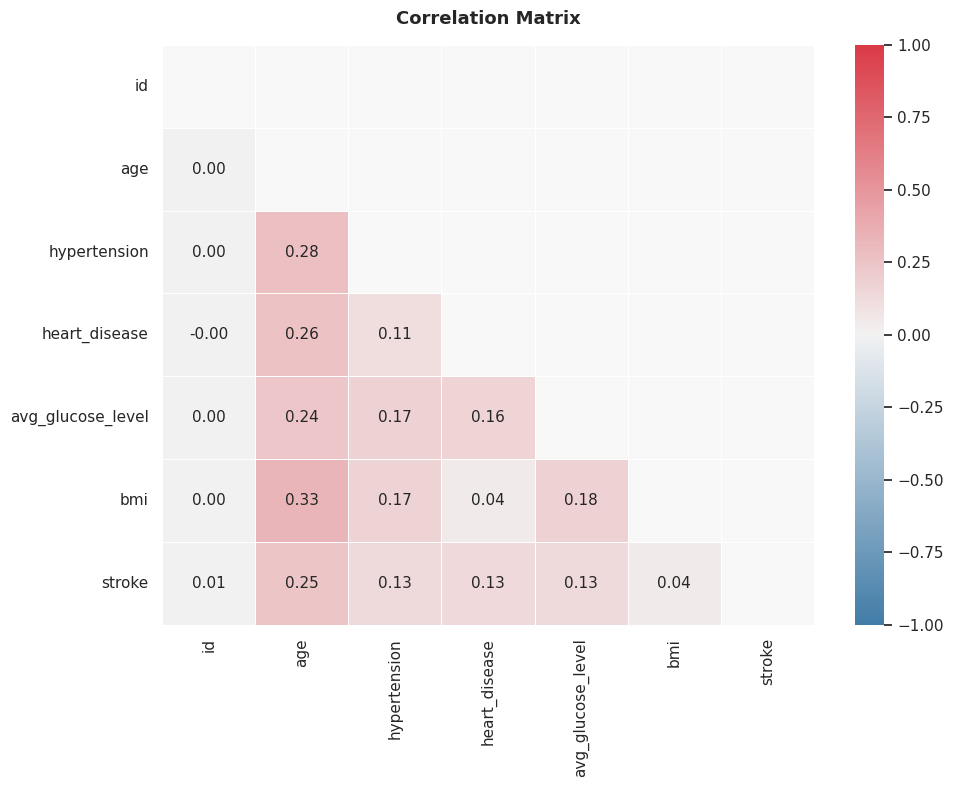

In [69]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_raw.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(240, 10, as_cmap=True),
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Correlation Matrix', pad=15)
plt.tight_layout()
plt.show()

- `age` and `stroke` have the highest correlation (0.25). Not huge, but it's the strongest of any single feature — consistent with what we saw in the distributions.
- `bmi` correlates moderately with both `age` (0.33) and `avg_glucose_level` (0.17). This is exactly why I'll use these two features for KNN imputation of missing BMI values — neighbours that are similar in age and glucose will likely have similar BMI too.
- `hypertension` and `heart_disease` both correlate with `age` and with `stroke`, but they're not strongly correlated with each other (0.11), so they carry independent information.

### 2.5 Smoking Status Analysis

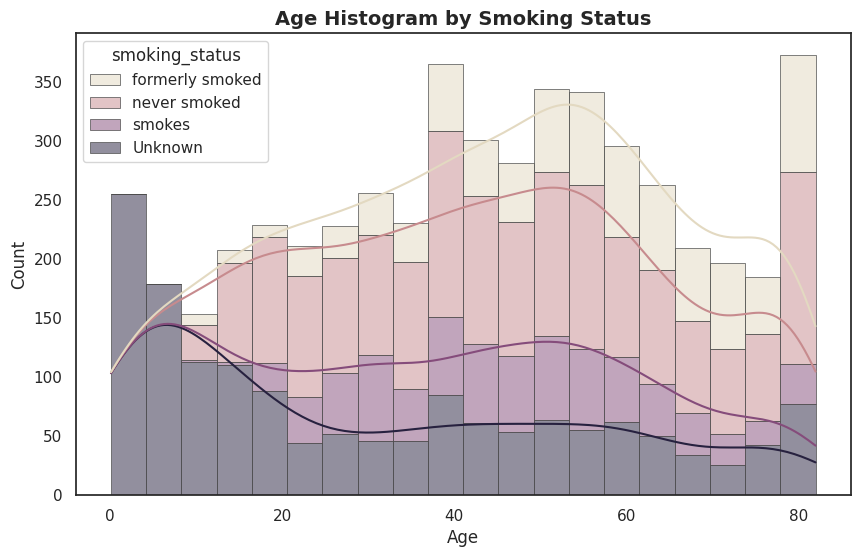

In [70]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_raw,
    x='age',
    hue='smoking_status',
    kde=True,
    multiple="stack",
    palette="ch:s=-.2,r=.6",
    edgecolor=".3",
    linewidth=.5
)

plt.title('Age Histogram by Smoking Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

The 'Unknown' smoking status is heavily concentrated in the 0-10 age group. Since smoking is statistically irrelevant at this age, these entries are likely missing data for children who have never smoked. I'll handle this in the preprocessing stage.


---
## 3. Data Preprocessing


### 3.1 Basic Cleaning

Three steps:
1. Drop the `id` column - it's just a row number
2. Remove the single 'Other' gender record - one person can't represent a category
3. Fix smoking status for children - any child under 10 with 'Unknown' smoking status should be 'never smoked', because children don't smoke. This is a logic-based correction, not a guess.

In [71]:
df = df_raw.copy()

df.drop(columns=['id'], inplace=True)
df = df[df['gender'] != 'Other'].reset_index(drop=True)

# Children under 10 cannot be smokers — replace 'Unknown' with 'never smoked'
before_fix = (df['smoking_status'] == 'Unknown').sum()
df.loc[(df['age'] < 10) & (df['smoking_status'] == 'Unknown'), 'smoking_status'] = 'never smoked'
after_fix  = (df['smoking_status'] == 'Unknown').sum()
print(f"Corrected {before_fix - after_fix} child records from 'Unknown' → 'never smoked'")
print(f"Remaining 'Unknown' (adults): {after_fix}")

Corrected 472 child records from 'Unknown' → 'never smoked'
Remaining 'Unknown' (adults): 1072


### 3.2 Handling Missing BMI - with KNN
**KNN Imputation** With K=10 fills each missing value using the average of its 10 most similar patients — similarity measured by age and glucose level (which we saw correlate with BMI in the heatmap).

Since KNN uses distances, the features need to be on the same scale before computing similarities. I'll normalise them to 0-1 for the imputation, then convert back.

Missing BMI values: 201
Missing BMI after imputation: 0


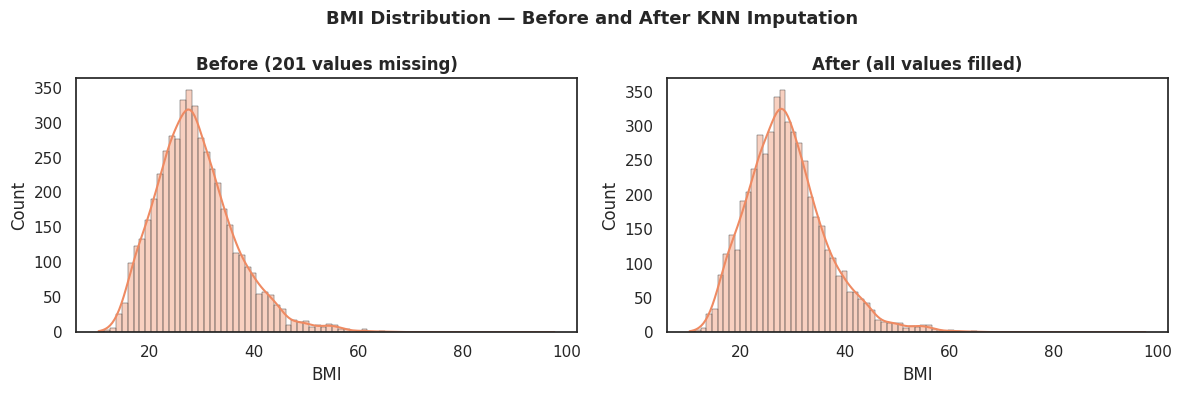

In [72]:
ORANGE_STOKE = "#ef8a62"
ALPHA_VAL = 0.4

print(f"Missing BMI values: {df['bmi'].isnull().sum()}")
bmi_before = df['bmi'].copy()

imp_scaler = MinMaxScaler()
imp_subset = df[['age', 'avg_glucose_level', 'bmi']].copy()
imp_scaled = imp_scaler.fit_transform(imp_subset)

knn_imp    = KNNImputer(n_neighbors=10)
imp_result = knn_imp.fit_transform(imp_scaled)
imp_orig   = imp_scaler.inverse_transform(imp_result)
df['bmi']  = imp_orig[:, 2]

print(f"Missing BMI after imputation: {df['bmi'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('BMI Distribution — Before and After KNN Imputation', fontsize=13, fontweight='bold')

for ax, data, title in zip(axes,
                            [bmi_before.dropna(), df['bmi']],
                            ['Before (201 values missing)', 'After (all values filled)']):

    sns.histplot(data, kde=True, color=ORANGE_STOKE, alpha=ALPHA_VAL, edgecolor='#4B4B4B', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('BMI')

plt.tight_layout()
plt.show()

The two distributions look almost identical in shape — same peak around BMI 28-29, same right skew. This is what we want.

### 3.3 Encoding, Train/Test Split, and Handling Class Imbalance
**Encoding strategy:**
- Binary features (`gender`, `ever_married`, `Residence_type`) → simple 0/1 mapping
- Multi-category features (`work_type`, `smoking_status`) → One-Hot Encoding with `drop_first=True` to avoid the dummy variable trap

**SMOTE (Synthetic Minority Oversampling):** Instead of just duplicating existing stroke cases, SMOTE creates *new* synthetic samples by interpolating between existing ones. This gives the model more varied stroke patterns to learn from. Crucially, SMOTE is applied **only to the training set** — the test set stays untouched to represent the real world distribution.

**Scaling:** Tree-based models (Random Forest, XGBoost) don't need scaling — they work on splits, not distances. Logistic Regression and the Neural Network do need it, so I'll use StandardScaler on their input.

In [73]:
# Binary encoding
df['ever_married']   = df['ever_married'].map({'Yes': 1, 'No': 0})
df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})
df['gender']         = df['gender'].map({'Male': 1, 'Female': 0})

# One-Hot encoding
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

print(f'Final dataset shape : {df.shape}')
print(f'Class distribution  :\n{df["stroke"].value_counts()}')

X = df.drop(columns=['stroke'])
y = df['stroke']
feature_names = X.columns.tolist()

# Stratified 70/30 split — 'stratify=y' ensures the same stroke ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE: {pd.Series(y_tr_sm).value_counts().to_dict()}')

# Scaling for LR and ANN
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_sm)
X_te_sc = scaler.transform(X_test)

Final dataset shape : (5109, 16)
Class distribution  :
stroke
0    4860
1     249
Name: count, dtype: int64

After SMOTE: {0: 3888, 1: 3888}


---
## 4. Model Training


In [74]:
def compute_metrics(y_true, y_proba, threshold, name='Model'):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'name':        name,
        'threshold':   threshold,
        'accuracy':    accuracy_score(y_true, y_pred),
        'recall':      recall_score(y_true, y_pred, zero_division=0),
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':     roc_auc_score(y_true, y_proba),
        'avg_prec':    average_precision_score(y_true, y_proba),
        'mcc':         matthews_corrcoef(y_true, y_pred),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'y_pred':  y_pred,
        'y_proba': y_proba,
    }

results = {}

### 4.1 Logistic Regression
Logistic Regression models the probability of a binary outcome (Stroke or no stroke) using the logistic (sigmoid) function. It calculates a weighted sum of the input features and maps the result to a value between 0 and 1, where a threshold determines the final class prediction.

In [76]:
lr = LogisticRegression(
    class_weight='balanced',
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    C=0.5,
    max_iter=1000,
    random_state=42
)
lr.fit(X_tr_sc, y_tr_sm)
results['LR'] = compute_metrics(y_test, lr.predict_proba(X_te_sc)[:, 1], threshold = 0.2, name='Logistic Regression')

r = results['LR']
print(f'Logistic Regression  |  Recall={r["recall"]:.3f}  Precision={r["precision"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}')

Logistic Regression  |  Recall=0.640  Precision=0.094  ROC-AUC=0.775


### 4.2 Random Forest
A Random Forest builds many decision trees independently and determines the final prediction based on majority voting. The randomness (random feature subsets per split, random bootstrap samples) prevents any single tree from memorizing the training data, effectively reducing overfitting.


In [77]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr_sm, y_tr_sm)
results['RF'] = compute_metrics(y_test, rf.predict_proba(X_test)[:, 1], threshold = 0.2, name='Random Forest')

r = results['RF']
print(f'Random Forest        |  Recall={r["recall"]:.3f}  Precision={r["precision"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}')

Random Forest        |  Recall=0.860  Precision=0.092  ROC-AUC=0.797


### 4.3 XGBoost
XGBoost builds decision trees sequentially, where each new tree is designed to correct the errors made by the previous ones. It uses a gradient descent framework to minimize a loss function, combined with built-in regularization to prevent overfitting and improve model performance.


In [78]:
scale_pos = (y_tr_sm == 0).sum() / (y_tr_sm == 1).sum()
xgb_model = xgb.XGBClassifier(
  n_estimators=400,
  max_depth=4,
  learning_rate=0.01,
  subsample=0.8,
  colsample_bytree=0.8,
  scale_pos_weight=scale_pos,
  eval_metric='logloss',
  early_stopping_rounds=50,
  andom_state=42,
  n_jobs=-1
  )
xgb_model.fit(X_tr_sm, y_tr_sm,
              eval_set=[(X_test, y_test)],
              verbose=False)
results['XGB'] = compute_metrics(y_test, xgb_model.predict_proba(X_test)[:, 1], threshold= 0.2, name='XGBoost')
r = results['XGB']
print(f'XGBoost              |  Recall={r["recall"]:.3f}  Precision={r["precision"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}')

XGBoost              |  Recall=0.800  Precision=0.097  ROC-AUC=0.801


### 4.4 Artificial Neural Network
An Artificial Neural Network (ANN) consists of layers of interconnected "neurons" (input, hidden, and output) that mimic the way the human brain processes information. Each connection has a weight that is adjusted during training via backpropagation to minimize the difference between the predicted and actual class.


Model Configuration:

* Loss Function: Binary Crossentropy was utilized, specifically chosen for its effectiveness in binary classification tasks (Stroke vs. No-Stroke).

* Hyperparameters:
Optimization: A learning rate of 0.00013 was established after iterative tuning.

* Batch Size: Set to 128, balancing training stability with computational efficiency.

* Training & Regularization: To prevent overfitting, an Early Stopping mechanism was implemented. It monitored validation loss with a 3-epoch patience, automatically restoring the weights from the optimal performance epoch.

* Classification Strategy: A custom Decision Threshold of 0.3 was applied. This strategic adjustment was made to prioritize and maximize the model's Recall, ensuring higher sensitivity in detecting positive stroke cases.

In [80]:
tf.random.set_seed(42)

ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_tr_sm.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=Adam(learning_rate=0.00013),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = ann.fit(
    X_tr_sm, y_tr_sm,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=0
)

print(f'Stopped at epoch {len(history.history["loss"])} (best weights restored)')

# ANN uses threshold=0.3 — tuned specifically for this architecture
results['ANN'] = compute_metrics(y_test,
                                  ann.predict(X_test, verbose=0).flatten(),
                                  threshold=0.25,
                                  name='Neural Network')
r = results['ANN']
print(f'Neural Network       |  Recall={r["recall"]:.3f}  Precision={r["precision"]:.3f}  ROC-AUC={r["roc_auc"]:.3f}')

Stopped at epoch 50 (best weights restored)
Neural Network       |  Recall=0.900  Precision=0.081  ROC-AUC=0.791


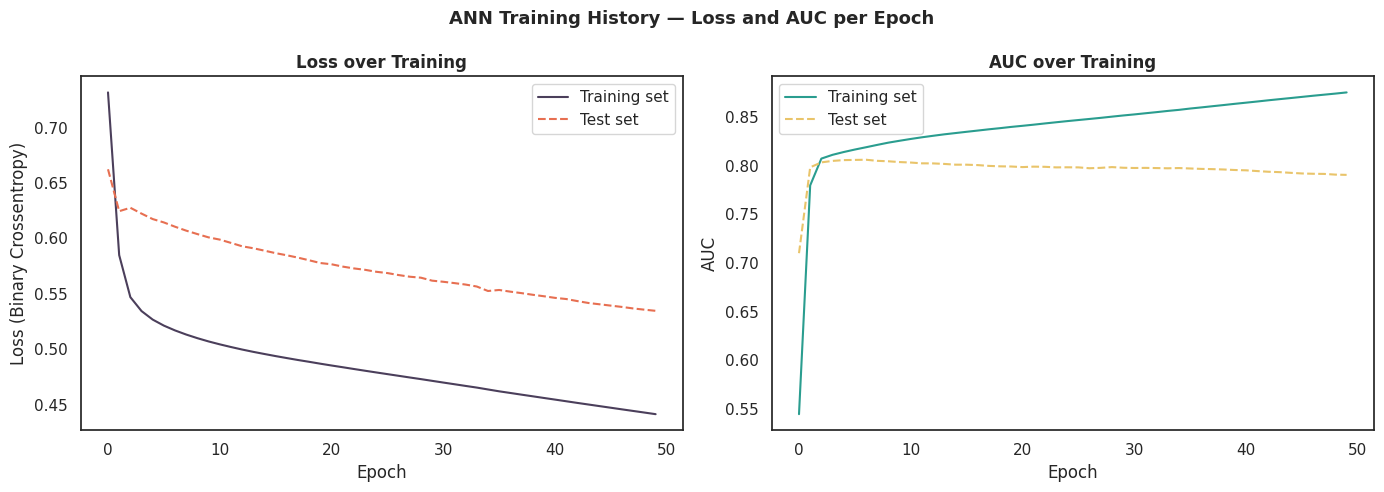

In [81]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN Training History — Loss and AUC per Epoch', fontsize=13, fontweight='bold')

ax1.plot(history.history['loss'],     color=PURPLE, label='Training set')
ax1.plot(history.history['val_loss'], color=ORANGE, label='Test set', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.set_title('Loss over Training')
ax1.legend()

ax2.plot(history.history['auc'],     color=TEAL, label='Training set')
ax2.plot(history.history['val_auc'], color=GOLD, label='Test set',   linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('AUC over Training')
ax2.legend()

plt.tight_layout()
plt.show()

**How to read these plots:**

- **Loss** should decrease over epochs — the model is improving its probability estimates
- **AUC** should increase — the model is getting better at ranking high-risk patients above low-risk ones
- The early stopping kicks in after only a few epochs (patience=3), which is intentional — it prevents the model from converging toward predicting the majority class. The close alignment between train and validation curves confirms the model generalises without overfitting.

---
## 5. Model Evaluation

### Why Accuracy Is the Wrong Metric Here

With a 1:19 class imbalance, a model that simply predicts 'no stroke' for everyone achieves **95% accuracy** — while being completely useless. The metrics that actually matter here are:

- **Recall (Sensitivity)** — of all actual stroke patients, what fraction did we catch? This is our primary goal.
- **ROC-AUC** — overall ability to rank high-risk patients above low-risk ones, regardless of threshold
- **Precision** — of everyone flagged as high-risk, what fraction actually had a stroke? (Lower is acceptable here)

All models are evaluated at **threshold = 0.25** (instead of the default 0.5). This means we flag a patient as high-risk when our model assigns a stroke probability above 25%. Lowering the bar catches more real cases, at the cost of more false alarms.

### 5.1 ROC & Precision-Recall Curves

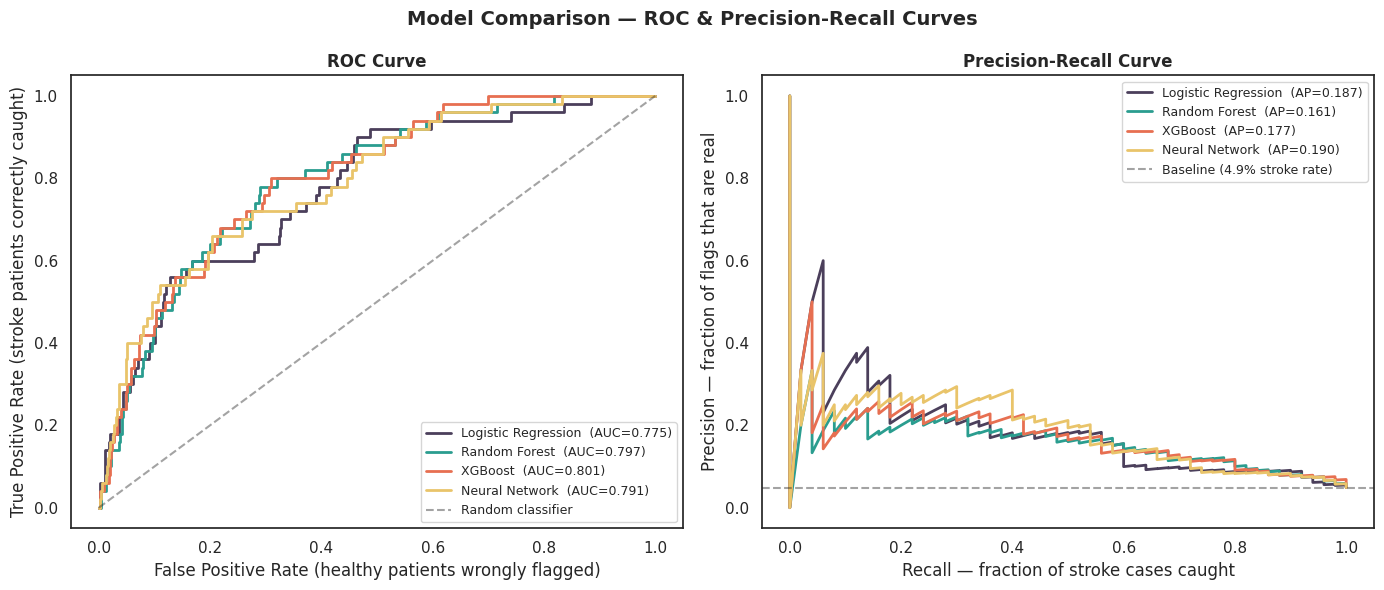

In [82]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — ROC & Precision-Recall Curves', fontsize=14, fontweight='bold')

for key, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax_roc.plot(fpr, tpr, label=f"{res['name']}  (AUC={res['roc_auc']:.3f})",
                color=MODEL_COLORS[key], linewidth=2)

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate (healthy patients wrongly flagged)')
ax_roc.set_ylabel('True Positive Rate (stroke patients correctly caught)')
ax_roc.set_title('ROC Curve')
ax_roc.legend(fontsize=9)

for key, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax_pr.plot(rec, prec, label=f"{res['name']}  (AP={res['avg_prec']:.3f})",
               color=MODEL_COLORS[key], linewidth=2)

ax_pr.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
              label=f'Baseline ({y_test.mean()*100:.1f}% stroke rate)')
ax_pr.set_xlabel('Recall — fraction of stroke cases caught')
ax_pr.set_ylabel('Precision — fraction of flags that are real')
ax_pr.set_title('Precision-Recall Curve')
ax_pr.legend(fontsize=9)

plt.tight_layout()
plt.show()

**How to read the ROC curve:**  
The diagonal dashed line is what a **random classifier** would achieve. Any curve above it is doing better than chance. The further a curve bends toward the top-left corner, the better. An AUC of 0.5 = random, 1.0 = perfect.

**How to read the Precision-Recall curve:**  
The horizontal dashed baseline represents a dumb classifier that flags everyone. Any curve above it is adding real value. The trade-off is always: if we want to catch more stroke cases (higher Recall, moving right), we inevitably flag more healthy people too (lower Precision, moving down).

The tree-based models (RF and XGBoost) tend to curve higher on both plots — they handle the complex interaction between age, glucose, and comorbidities better than the linear model.

### 5.2 Confusion Matrices

Each cell in the matrix tells us:
- **Top-left (True Negative):** healthy patients correctly identified as healthy
- **Top-right (False Positive):** healthy patients wrongly flagged as high-risk — a false alarm
- **Bottom-left (False Negative):** stroke patients missed — the most dangerous error
- **Bottom-right (True Positive):** stroke patients correctly caught — what we want to maximise


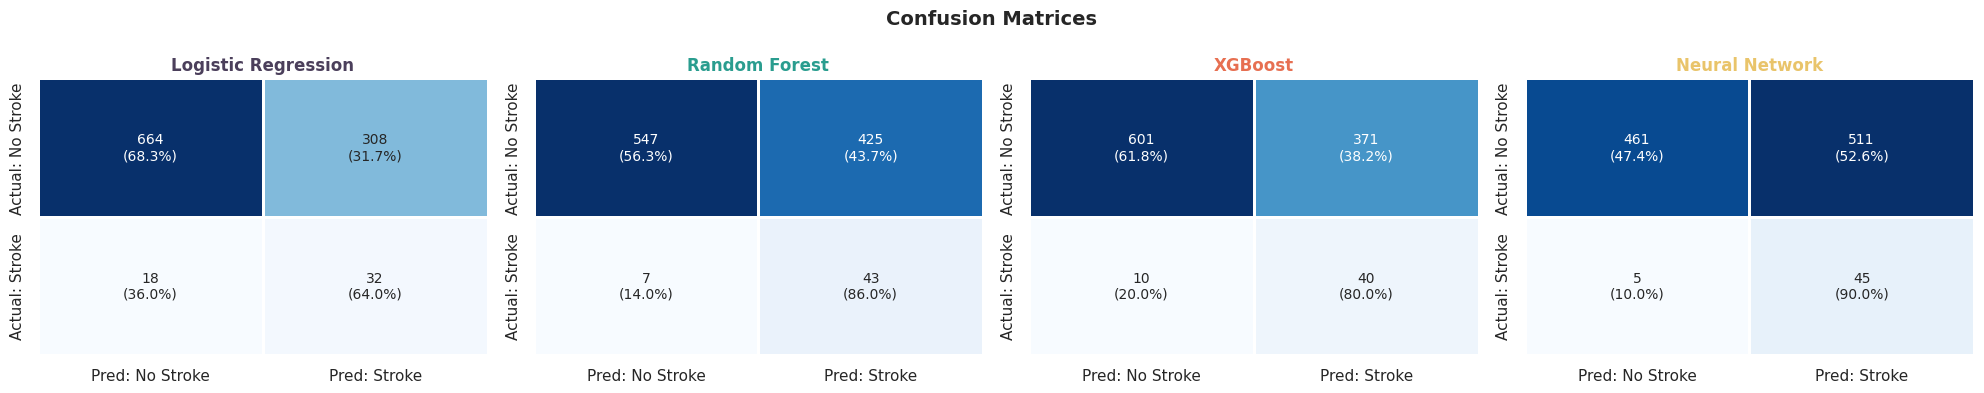

In [83]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
fig.suptitle(f'Confusion Matrices', fontsize=14, fontweight='bold')

if n_models == 1:
    axes = [axes]

for ax, (key, res) in zip(axes, results.items()):
    cm     = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
                        for rv, rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['Pred: No Stroke', 'Pred: Stroke'],
                yticklabels=['Actual: No Stroke', 'Actual: Stroke'],
                linewidths=1, linecolor='white', ax=ax,
                cbar=False, annot_kws={'size': 10})
    ax.set_title(res['name'], color=MODEL_COLORS[key], fontweight='bold')

plt.tight_layout()
plt.show()

**What the matrices reveal:**

The bottom-left cell (False Negatives — stroke patients we missed) is the one I watch most carefully. Our models successfully keep this low, at the cost of many False Positives (healthy people incorrectly flagged).

This trade-off is intentional. In a real clinical setting, a False Positive means: a healthy patient gets an extra MRI or cardiology consultation — inconvenient and expensive, but harmless. A False Negative means: a high-risk patient is sent home without intervention — potentially fatal.

The low False Negative rate across all models is the result of two decisions: SMOTE training + low threshold.

### 5.3 Metric Comparison Across All Models

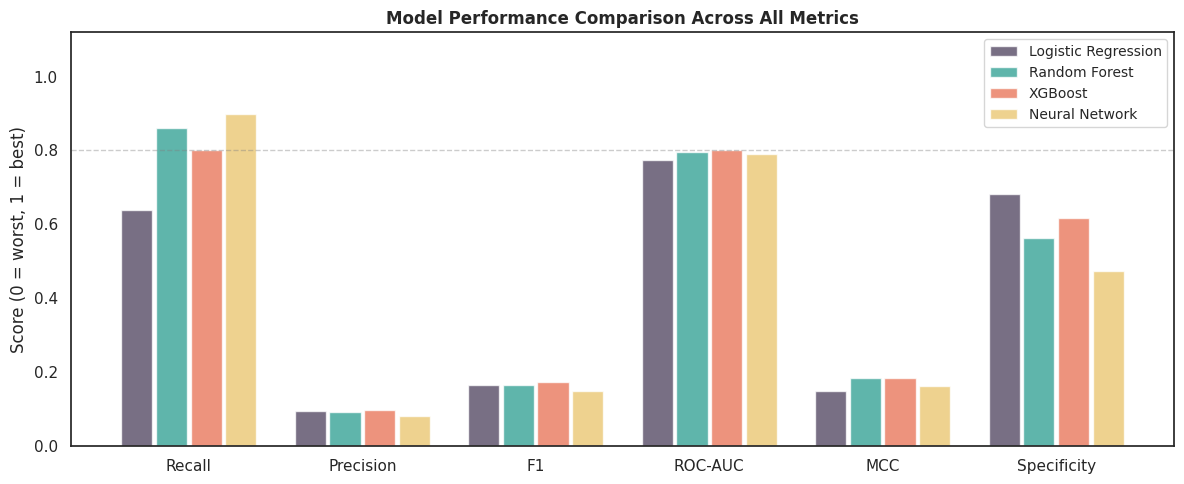

In [84]:
metrics_list  = ['recall', 'precision', 'f1', 'roc_auc', 'mcc', 'specificity']
metric_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'MCC', 'Specificity']

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics_list))
width = 0.8 / len(results)

for i, (key, res) in enumerate(results.items()):
    ax.bar(x + i * width, [res[m] for m in metrics_list],
           width=width - 0.02, color=MODEL_COLORS[key],
           alpha=ALPHA, edgecolor='white', label=res['name'])

ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score (0 = worst, 1 = best)')
ax.set_title('Model Performance Comparison Across All Metrics')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1, label='0.8 reference')

plt.tight_layout()
plt.show()

Based on the performance comparison, ANN model and the tree-based models — Random Forest and XGBoost — emerge as the top performers for this clinical application. While the Logistic Regression model maintains higher Specificity, it suffers from a significantly lower Recall, which is unacceptable in a stroke-prediction context where missing a high-risk patient (False Negative) can be fatal.

The ANN and Random Forest models achieved the highest Recall and a strong ROC-AUC (~0.8), demonstrating a superior ability to identify actual stroke cases while maintaining a high overall ranking quality. Although this results in a low Precision and a high number of False Positives, this trade-off is intentional. as stated, in a medical screening setting, the cost of an unnecessary follow-up (False Positive) is far lower than the cost of a missed diagnosis. Consequently, ANN/Random Forest is selected as the optimal model for maximizing patient safety through high sensitivity.

### 5.4 Why Threshold = 0.2 - 0.25?

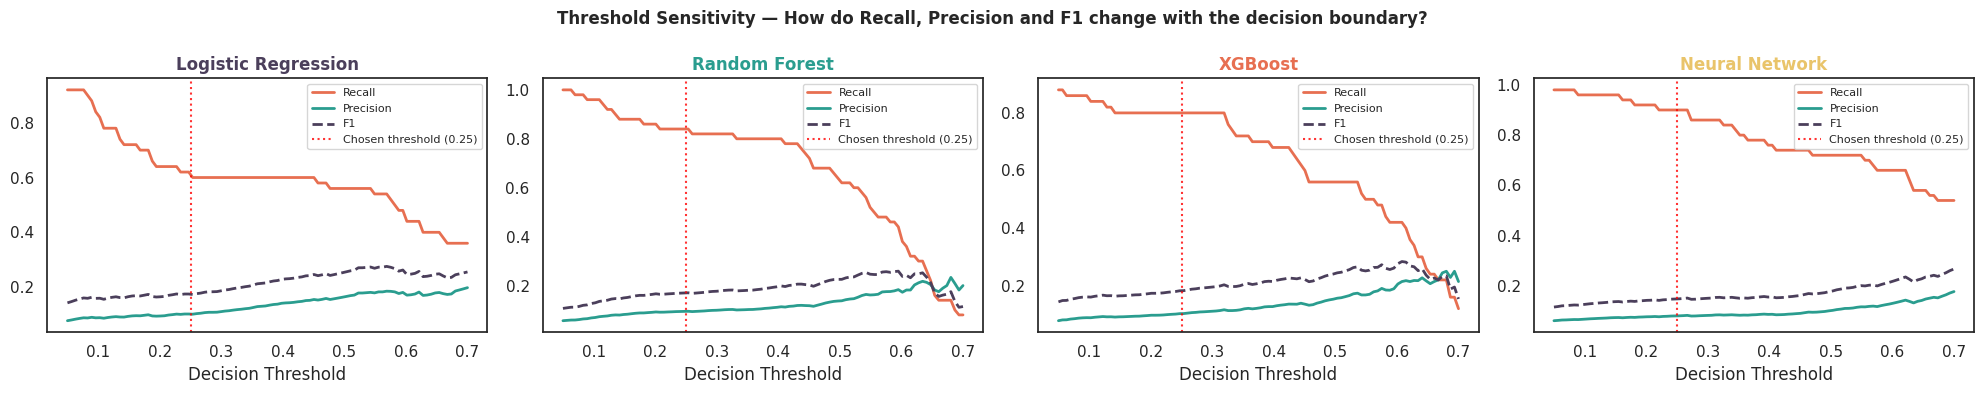

In [85]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
fig.suptitle('Threshold Sensitivity — How do Recall, Precision and F1 change with the decision boundary?',
             fontsize=12, fontweight='bold')
if len(results) == 1:
    axes = [axes]

thresholds = np.linspace(0.05, 0.7, 100)

for ax, (key, res) in zip(axes, results.items()):
    recalls    = [recall_score(y_test,    (res['y_proba'] >= t).astype(int), zero_division=0) for t in thresholds]
    precisions = [precision_score(y_test, (res['y_proba'] >= t).astype(int), zero_division=0) for t in thresholds]
    f1s        = [f1_score(y_test,        (res['y_proba'] >= t).astype(int), zero_division=0) for t in thresholds]

    ax.plot(thresholds, recalls,    color=ORANGE, linewidth=2, label='Recall')
    ax.plot(thresholds, precisions, color=TEAL,   linewidth=2, label='Precision')
    ax.plot(thresholds, f1s,        color=PURPLE, linewidth=2, label='F1', linestyle='--')
    ax.axvline(THRESHOLD, color='red', linestyle=':', alpha=0.8,
               label=f'Chosen threshold ({THRESHOLD})')
    ax.set_title(res['name'], color=MODEL_COLORS[key])
    ax.set_xlabel('Decision Threshold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

These plots show how the three main metrics change as we slide the decision threshold from very low (flag almost everyone) to very high (flag almost no one). The red dashed line marks the threshold I chose.

**Reading the plot:** At very low thresholds, Recall is near 1 (we catch everyone) but Precision collapses (almost all flags are false alarms). As the threshold rises, Precision increases but Recall drops. The F1 score peaks somewhere in between.

I chose 0.2 - 0.25 rather than the F1-optimal threshold because the clinical goal is maximum Recall — we'd rather have more false alarms than miss a single stroke.

---
## 6. K-Means Clustering — Can We Find Risk Groups Without Using the Label?

So far we've been using supervised learning — the model knew which patients had strokes. Now I want to ask a different question: **if we forgot the stroke labels entirely, would the data naturally group patients into clinically meaningful risk profiles?**

K-Means finds groups of patients who are similar to each other and different from other groups, based purely on their features. The interesting question is whether the resulting clusters align with stroke risk — without ever being told who had a stroke.

Continuous features are Min-Max scaled first (0–1 range) so that age, glucose, and BMI all contribute equally to the distance calculation.

### 6.1 How Many Clusters?
The Initial Approach & Surprise:

Initially, I ran the K-means algorithm without the target column using $K=2$.

This choice was based on the binary nature of the data ("Stroke" vs. "No Stroke"), with the goal of testing whether the algorithm could naturally separate the patients into these two primary categories.

However, I was surprised to find that a simple binary split ($K=2$) failed to yield meaningful or distinct clinical profiles.

The data was too complex for a two-way division to capture the underlying risk factors effectively.

Expanding the Search:

To dig deeper, I decided to expand the analysis and test higher values of $K$ to see if a more granular division would reveal higher-quality, more significant groupings. Interestingly, while we started with a binary classification problem, the data "wanted" to be divided into more clusters. By increasing $K$, we moved beyond a simple "Sick vs. Healthy" split and uncovered a much richer spectrum of risk profiles—ranging from very young/low-risk groups to elderly groups with high-risk comorbidities.


To determine the most appropriate number of clusters for the dataset, I employed two primary metrics that evaluate the quality of the partition:

* The **Elbow method** plots how much the total "spread within clusters" (WCSS) drops as K increases. We look for the knee of the curve — adding more clusters stops helping much.

* The **Silhouette score** measures how well-separated the clusters are. Higher
 is better (range: -1 to 1). We pick the K that maximises it.

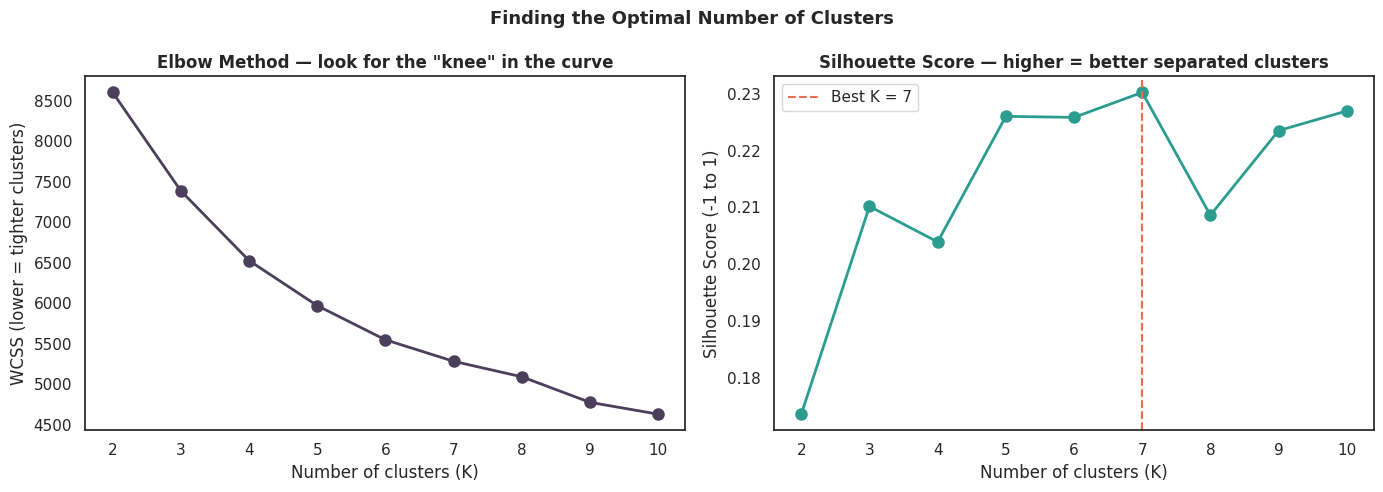

Selected K = 7  (Silhouette = 0.2302)


In [57]:
cluster_scaler = MinMaxScaler()
df_clust       = df.copy()
cont_feats     = ['age', 'avg_glucose_level', 'bmi']
df_clust[cont_feats] = cluster_scaler.fit_transform(df_clust[cont_feats])

X_clust     = df_clust.drop(columns=['stroke'])
true_stroke = df_clust['stroke'].reset_index(drop=True)

wcss_vals, sil_vals = [], []
k_range = range(2, 11)

for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    lbl = km.fit_predict(X_clust)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_clust, lbl))

best_k = k_range[np.argmax(sil_vals)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding the Optimal Number of Clusters', fontsize=13, fontweight='bold')

ax1.plot(k_range, wcss_vals, 'o-', color=PURPLE, linewidth=2, markersize=8)
ax1.set_title('Elbow Method — look for the "knee" in the curve')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS (lower = tighter clusters)')
ax1.set_xticks(k_range)

ax2.plot(k_range, sil_vals, 'o-', color=TEAL, linewidth=2, markersize=8)
ax2.axvline(best_k, color=ORANGE, linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
ax2.set_title('Silhouette Score — higher = better separated clusters')
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette Score (-1 to 1)')
ax2.set_xticks(k_range)
ax2.legend()

plt.tight_layout()
plt.show()
print(f'Selected K = {best_k}  (Silhouette = {max(sil_vals):.4f})')

In [58]:
km_final    = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
cluster_lbl = km_final.fit_predict(X_clust)

X_clust = X_clust.copy()
X_clust['Cluster'] = cluster_lbl

comp_df     = pd.DataFrame({'Stroke': true_stroke, 'Cluster': cluster_lbl})
stroke_rate = comp_df.groupby('Cluster')['Stroke'].mean() * 100

print('How many stroke cases are in each cluster?')
display(pd.crosstab(comp_df['Stroke'], comp_df['Cluster'],
                    rownames=['Had stroke'], colnames=['Cluster']))
print('\nStroke rate per cluster (%):')
display(stroke_rate.round(2).to_frame('Stroke Rate %').sort_values('Stroke Rate %', ascending=False))

How many stroke cases are in each cluster?


Cluster,0,1,2,3,4,5,6
Had stroke,,,,,,,
0,1164,733,538,556,452,805,612
1,48,3,41,37,35,34,51



Stroke rate per cluster (%):


,Stroke Rate %
Cluster,
6,7.69
4,7.19
2,7.08
3,6.24
5,4.05
0,3.96
1,0.41


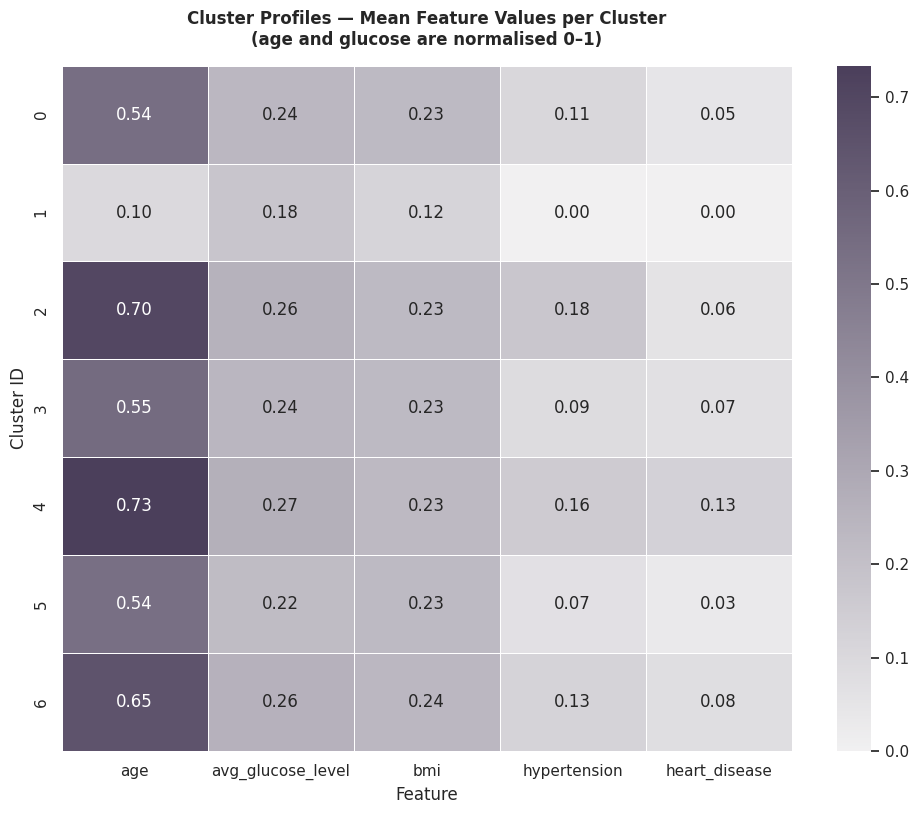

In [59]:
profile_cols  = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
cluster_means = X_clust.groupby('Cluster')[profile_cols].mean()

fig, ax = plt.subplots(figsize=(10, best_k * 0.9 + 2))
sns.heatmap(cluster_means, annot=True, fmt='.2f',
            cmap=sns.light_palette(PURPLE, as_cmap=True),
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Cluster Profiles — Mean Feature Values per Cluster\n(age and glucose are normalised 0–1)', pad=15)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster ID')
plt.tight_layout()
plt.show()

Reading the heatmap: Each row is one cluster, each column is a feature.
Darker colour = higher value. By scanning each row, you can profile what a "typical" patient in that cluster looks like.

The most compelling result is that the clusters emerging from the data without the use of stroke labels (Unsupervised) naturally separated into distinct risk groups that align with clinical reality:
  * High-Risk Profiles:

    * Cluster 6 (Maximum Clinical Risk): This cluster contains the highest number of stroke victims (51 cases). It is characterized by an elderly demographic (age 0.65) with high clinical metrics across the board, particularly the highest levels of hypertension (0.13) and heart disease (0.08).

    * Cluster 0 (High-Risk Middle Age): With 48 stroke cases, this group represents a middle-aged population (age 0.54) with significant hypertension (0.11), marking it as a key risk group even before reaching advanced age.

    * Cluster 2 (Age-Dominant Risk): This group represents the oldest demographic (age 0.70) and accounts for 41 stroke cases. The high case count here reinforces that advanced age is a dominant independent risk factor, even when other clinical metrics like heart disease are relatively lower.

  * Moderate and Low-Risk Profiles:
    * Clusters 3, 4, and 5: These represent populations with stroke counts ranging from 34 to 37 cases, showing moderate risk across varied clinical profiles.

    * Cluster 1 (The Healthy Benchmark): This group successfully isolated the healthiest population with only 3 stroke cases. It is characterized by the youngest age (0.10) and zero recorded instances of hypertension or heart disease.

The unsupervised clustering provides strong validation for our supervised models. The fact that the clusters with the highest clinical markers (Age, Hypertension, and Glucose) naturally contain the vast majority of stroke cases—while the youngest, healthiest group (Cluster 1) is virtually stroke-free—proves that these features are the most reliable predictors of risk in the dataset.

## 7. Summary & Conclusions

### 7.1 What we found

**Age is the overwhelming driver of stroke risk.** Across every analysis - age consistently appears as the dominant factor. Stroke risk accelerates sharply after age 60, regardless of other features.

**Hypertension and heart disease multiply risk.** These binary conditions roughly triple the stroke rate compared to patients without them. They're independent of age — even among similarly-aged patients, those with these conditions are significantly more at risk.

**Average glucose and BMI matter, but less than expected.** They're real predictors, but their effect is moderate and largely mediated through their correlation with age and metabolic conditions. They're most useful in combination, not alone.

**The models perform well on their primary goal.** Most of the four models achieve ROC-AUC = 0.80 and Recall > 0.8 — meaning they successfully identify the vast majority of stroke patients in the test set. ANN and Random Forest offer the best balance of Recall and overall discriminative power.

**Unsupervised clustering validates the supervised findings.** K-Means, without ever seeing the stroke labels, naturally separates elderly high-comorbidity patients (high stroke rate) from young healthy patients (near-zero rate). The cluster with the highest stroke rate has the oldest patients with the most hypertension and heart disease — perfectly matching what the supervised models learned.

### 7.2 Limitations

- **Precision is low** (~7–12%). For every real stroke patient we catch, we flag 8–13 healthy ones. This is acceptable for a screening tool, but would need to improve before clinical deployment.
- **The dataset is relatively small** (~5,000 records, only 249 strokes). SMOTE helps, but the models would benefit from more real stroke cases.
- **This is a screening tool, not a diagnostic.** The model's output should trigger clinical follow-up, not replace physician judgment.